> **License & Attribution**  
> This notebook is a derivative of [LLMs-from-scratch](https://github.com/rasbt/LLMs-from-scratch)  
> by Sebastian Raschka, licensed under the Apache License 2.0.  
> Modifications made by [enhennnn].  
>  
> SPDX-License-Identifier: Apache-2.0  
> For the full license text, see the [LICENSE](LICENSE) file in this repository

## 目录

1. 准备数据集
2. 创建Dataset和collate_fn
3. 创建Dataloader
4. 加载预训练的大模型
5. 指令微调
6. 保存模型回复
7. 评价模型回复


&nbsp;
## 1. 准备数据集

In [1]:
import json
import os
import urllib

def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        with urllib.request.urlopen(url) as response:
            text_data = response.read().decode("utf-8")
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(text_data)
    else:
        with open(file_path, "r", encoding="utf-8") as file:
            text_data = file.read()
    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)
    return data

file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


- 在这里，我们使用Alpace风格的提示词格式

In [2]:
# entry包含"instruction"、"input"和"output"三个key
# 这里将"instruction"和"input"提出来
def format_input(entry):

    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n"
        f"### Instruction:\n"
        f"{entry['instruction']}"
    )
    input_text = (
        f"\n\n"
        f"### Input:\n"
        f"{entry['input']}"  if entry["input"] else ""
    )
    
    return instruction_text + input_text

In [3]:
# 将第50条数据的instruction和input提出来
model_input = format_input(data[50])
# 得到第50条数据的output作为response
desired_response = f"\n\n### Response:\n{data[50]['output']}"
# 组合起来
print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion

### Response:
The correct spelling is 'Occasion.'


- 划分训练集、验证集和测试集

In [4]:
# 自定义训练集、测试集和验证集的大小
train_portion = int(len(data) * 0.85) 
test_portion = int(len(data) * 0.1)  
val_portion = len(data) - train_portion - test_portion  

# 划分数据集
train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


&nbsp;
## 2. 创建Dataset和collate_fn

In [5]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = []
        # entry包含"instruction"、"input"和"output"三个key
        for entry in data:
            # 将"instruction"和"input"提出来
            instruction_plus_input = format_input(entry)
            # 将"output"提出来
            response_text = f"\n\n### Response:\n{entry['output']}"
            # 组个起来并token化
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]
    
    def __len__(self):
        return len(self.data)

- 我们已经知道怎么创建Dataset了，但是还需要定义collate_fn，确定Dataset的组织方法

In [6]:
import tiktoken

# 使用GPT2的tokenizer
tokenizer = tiktoken.get_encoding("gpt2")
# 显示<|endoftext|>的token ID，后续作为padding材料
print("<|endoftext|>的token ID:", tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

<|endoftext|>的token ID: [50256]


- 在ch5，我们对所有长短不一的数据进行padding，填充至所有数据中最长值

- 在这里，我们定义“collate”函数，该函数以batch为单位，每个batch中的数据padding到相同的长度

In [7]:
def custom_collate_draft_1(batch, pad_token_id=50256, device="cpu"):
    # 将最大长度增加1，即后面添加一个token作为结束符
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst = []

    for item in batch:
        new_item = item.copy()
        # 下面这行在这里看起来很奇怪
        new_item += [pad_token_id]
        padded = (new_item + [pad_token_id] *(batch_max_length - len(new_item)))
        
        inputs = torch.tensor(padded[:-1])
        inputs_lst.append(inputs)

    # 堆积起来并输送给device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor

batch = ([0, 1, 2, 3, 4],[5, 6],[7, 8, 9])
print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


In [8]:
def custom_collate_draft_2(batch, pad_token_id=50256, device="cpu"):
    # 将最大长度增加1，即后面添加一个token作为结束符
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst, targets_lst = [], []
    
    for item in batch:
        new_item = item.copy()
        # 需要在最后填充一个token才方便找targets
        new_item += [pad_token_id]
        padded = (new_item + [pad_token_id] * (batch_max_length - len(new_item)))
        
        inputs = torch.tensor(padded[:-1]) 
        targets = torch.tensor(padded[1:]) 
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

# targets就是inputs向后移一个位置
inputs, targets = custom_collate_draft_2(batch)
print("inputs:\n", inputs)
print("targets:\n", targets)

inputs:
 tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
targets:
 tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


In [9]:
# Pytorch的CrossEntropyLoss的ignore_index默认为-100
def custom_collate_fn(batch, pad_token_id=50256, ignore_index=-100, allowed_max_length=None, device="cpu"):
    # 将最大长度增加1，即后面添加一个token作为结束符
    batch_max_length = max(len(item)+1 for item in batch)
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        padded = (new_item + [pad_token_id] * (batch_max_length - len(new_item)))
        inputs = torch.tensor(padded[:-1]) 
        targets = torch.tensor(padded[1:]) 

        # 对targets进行改造
        # 找出targets里，所有是pad_token_id的位置
        mask = targets == pad_token_id
        # 拿到这些位置的索引
        indices = torch.nonzero(mask).squeeze()
        # 如果pad_token_id出现不止一次
        if indices.numel() > 1:
            # 从第2个开始全部改为ignore_index
            targets[indices[1:]] = ignore_index

        # 如果太长了就截断
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

inputs, targets = custom_collate_fn(batch)
print("inputs:\n", inputs)
print("targets:\n", targets)

inputs:
 tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
targets:
 tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


&nbsp;
## 3. 创建Dataloader

In [ ]:
from functools import partial

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 后续调用custom_collate_fn函数无需写device和allowed_max_length参数
customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)

In [13]:
from torch.utils.data import DataLoader

torch.manual_seed(123)

num_workers = 0
batch_size = 8

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [14]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([8, 61]) torch.Size([8, 61])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 75]) torch.Size([8, 75])
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 79]) torch.Size([8, 79])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 83]) torch.Size([8, 83])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 71]) torch.Size([8, 71])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 65]) torch.Size([8, 65])
torch.Size([8, 68]) torch.

&nbsp;
## 4. 加载预训练的大模型

- 此处加载gpt2-medium(355M)模型

In [16]:
from gpt_download import download_and_load_gpt2
from load_gpt_model import GPTModel, load_weights_into_gpt

BASE_CONFIG = {
    "vocab_size": 50257,     
    "context_length": 1024,  
    "drop_rate": 0.0,        
    "qkv_bias": True        
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

File already exists and is up-to-date: gpt2\355M\checkpoint
File already exists and is up-to-date: gpt2\355M\encoder.json
File already exists and is up-to-date: gpt2\355M\hparams.json
File already exists and is up-to-date: gpt2\355M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\355M\model.ckpt.index
File already exists and is up-to-date: gpt2\355M\model.ckpt.meta
File already exists and is up-to-date: gpt2\355M\vocab.bpe


In [ ]:
from load_gpt_model import generate, text_to_token_ids, token_ids_to_text

torch.manual_seed(123)

input_text = format_input(val_data[0])

token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)

# 完整输出
generated_text = token_ids_to_text(token_ids, tokenizer)
print(generated_text)

# 从生成的文本开始，去除非必要输出，去除"### Response:"和空格
response_text = generated_text[len(input_text):].replace("### Response:", "").strip()
print("------------------------------------------------------")
print(response_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the
------------------------------------------------------
The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


&nbsp;
## 5. 指令微调

In [32]:
from load_gpt_model import calc_loss_loader, train_model_simple

torch.manual_seed(123)
model.to(device)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

# 微调前的结果
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.8259090900421144
Validation loss: 3.7619332790374758


In [33]:
import time

torch.manual_seed(123)

num_epochs = 2
optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)

start_time = time.time()
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)
end_time = time.time()

execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.637, Val loss 2.626
Ep 1 (Step 000005): Train loss 1.174, Val loss 1.102
Ep 1 (Step 000010): Train loss 0.872, Val loss 0.944
Ep 1 (Step 000015): Train loss 0.857, Val loss 0.906
Ep 1 (Step 000020): Train loss 0.776, Val loss 0.881
Ep 1 (Step 000025): Train loss 0.754, Val loss 0.859
Ep 1 (Step 000030): Train loss 0.799, Val loss 0.836
Ep 1 (Step 000035): Train loss 0.714, Val loss 0.808
Ep 1 (Step 000040): Train loss 0.672, Val loss 0.806
Ep 1 (Step 000045): Train loss 0.633, Val loss 0.789
Ep 1 (Step 000050): Train loss 0.663, Val loss 0.783
Ep 1 (Step 000055): Train loss 0.760, Val loss 0.763
Ep 1 (Step 000060): Train loss 0.719, Val loss 0.743
Ep 1 (Step 000065): Train loss 0.653, Val loss 0.735
Ep 1 (Step 000070): Train loss 0.532, Val loss 0.729
Ep 1 (Step 000075): Train loss 0.569, Val loss 0.728
Ep 1 (Step 000080): Train loss 0.605, Val loss 0.725
Ep 1 (Step 000085): Train loss 0.509, Val loss 0.709
Ep 1 (Step 000090): Train loss 0.562, Val loss

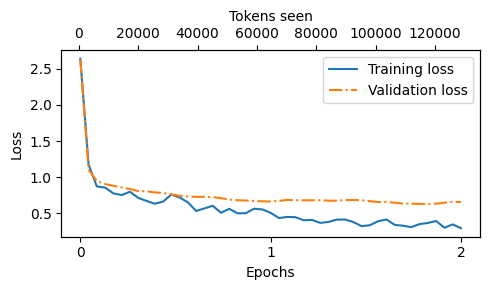

In [34]:
from load_gpt_model import plot_losses

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

&nbsp;
## 6. 保存模型回复

In [ ]:
torch.manual_seed(123)

# 显示几条测试集内容，对比正确回复和模型回复的区别
for entry in test_data[:3]:

    input_text = format_input(entry)
    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
    )

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a cheetah.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> The type of cloud associated with thunderstorms is a cumulus cloud.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Pre

In [ ]:
from tqdm import tqdm

# 保存模型在测试集上的回复，保存为instruction-data-with-response.json文件
for i, entry in tqdm(enumerate(test_data), total=len(test_data)):

    input_text = format_input(entry)
    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()
    
    test_data[i]["model_response"] = response_text


with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4) 

100%|██████████| 110/110 [01:50<00:00,  1.01s/it]


In [38]:
import re

# 保存模型
file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

Model saved as gpt2-medium355M-sft.pth
